# 03 - Riesgo por repositorio y conclusiones

Notebook de cierre: regenera dataset consolidado, valida contrato mínimo de `analysis.json` y extrae conclusiones dinámicas.

## Generación y validación del dataset consolidado

`analyzer/generate_analysis.py` es el punto oficial de consolidación. Este notebook ejecuta el generador en modo seguro (`--skip-notebooks`) para evitar recursión entre la generación de `analysis.json` y la ejecución de notebooks.

In [1]:
from __future__ import annotations

import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'analyzer' / 'generate_analysis.py').exists():
            return candidate
    return Path.cwd()


root = find_project_root()
generator = root / 'analyzer' / 'generate_analysis.py'
analysis_path = root / 'data' / 'results' / 'analysis.json'

result = subprocess.run(
    ['python3', str(generator), '--skip-notebooks'],
    cwd=str(root),
    capture_output=True,
    text=True,
    check=False,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('Falló la generación de analysis.json con --skip-notebooks')

assert analysis_path.exists(), f'No existe archivo consolidado: {analysis_path}'
analysis = json.loads(analysis_path.read_text(encoding='utf-8'))

print(f'analysis.json actualizado en: {analysis_path}')

Analysis generated at: /home/leocast/Desktop/Ciberseguridad/Proyecto/data/results/analysis.json
Analysis unchanged. Skipping notebook execution.

analysis.json actualizado en: /home/leocast/Desktop/Ciberseguridad/Proyecto/data/results/analysis.json


In [2]:
# Validación de schema mínimo
assert 'metadata' in analysis, 'Falta metadata'
assert 'repositories' in analysis, 'Falta repositories'
assert 'cross_repo_analysis' in analysis, 'Falta cross_repo_analysis'

for repo in analysis.get('repositories', []) or []:
    metrics = repo.get('metrics', {}) or {}
    vulns = repo.get('vulnerabilities', {}) or {}
    codeql = repo.get('codeql', {}) or {}

    assert 'risk_score' in metrics, f"Falta metrics.risk_score en {repo.get('name')}"
    assert 'risk_score_raw' in metrics, f"Falta metrics.risk_score_raw en {repo.get('name')}"
    assert 'by_type' in vulns, f"Falta vulnerabilities.by_type en {repo.get('name')}"
    assert 'with_fix_available' in vulns, f"Falta vulnerabilities.with_fix_available en {repo.get('name')}"
    assert 'by_level' in codeql, f"Falta codeql.by_level en {repo.get('name')}"

assert 'common_weakness_ranking' in analysis.get('cross_repo_analysis', {}), 'Falta cross_repo_analysis.common_weakness_ranking'

print('Schema mínimo validado correctamente.')

Schema mínimo validado correctamente.


In [3]:
repo_rows = []
cicd_rows = []
for repo in analysis.get('repositories', []) or []:
    repo_rows.append({
        'name': repo.get('name', 'unknown'),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
        'codeql_issues': repo.get('codeql', {}).get('total_issues', 0),
        'cicd_findings': repo.get('cicd', {}).get('total_findings', 0),
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerability_density': repo.get('metrics', {}).get('vulnerability_density', 0.0),
        'risk_score_raw': repo.get('metrics', {}).get('risk_score_raw', 0.0),
        'risk_score': repo.get('metrics', {}).get('risk_score', 0.0),
    })

    for finding in repo.get('cicd', {}).get('items', []) or []:
        cicd_rows.append({
            'repo': repo.get('name', 'unknown'),
            'workflow': finding.get('workflow', 'unknown'),
            'issue': finding.get('issue', 'unknown'),
        })

df_repo = pd.DataFrame(repo_rows)
df_cicd = pd.DataFrame(cicd_rows) if cicd_rows else pd.DataFrame(columns=['repo', 'workflow', 'issue'])

if df_repo.empty:
    df_repo = pd.DataFrame(columns=['name','vulnerabilities','codeql_issues','cicd_findings','components','vulnerability_density','risk_score_raw','risk_score'])

df_repo = df_repo.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_repo

,name,vulnerabilities,codeql_issues,cicd_findings,components,vulnerability_density,risk_score_raw,risk_score
0,deepagents,10,11,2,2276,0.439367,23.15,2.31
1,docs,5,0,0,502,0.996016,9.00,0.90
2,streaming-cookbook,4,0,0,899,0.444939,8.00,0.80
3,langsmith-java,2,0,0,14,14.285714,6.00,0.60
4,langchain,1,13,2,2330,0.042918,1.17,0.12
5,langsmith-go,0,0,0,31,0.000000,0.00,0.00


In [4]:
ranking = df_repo[['name', 'risk_score', 'risk_score_raw']].sort_values('risk_score', ascending=False).reset_index(drop=True)
comparison = df_repo[['name', 'vulnerabilities', 'codeql_issues', 'cicd_findings', 'components', 'vulnerability_density', 'risk_score']]

display(ranking)
display(comparison)

,name,risk_score,risk_score_raw
0,deepagents,2.31,23.15
1,docs,0.90,9.00
2,streaming-cookbook,0.80,8.00
3,langsmith-java,0.60,6.00
4,langchain,0.12,1.17
5,langsmith-go,0.00,0.00


,name,vulnerabilities,codeql_issues,cicd_findings,components,vulnerability_density,risk_score
0,deepagents,10,11,2,2276,0.439367,2.31
1,docs,5,0,0,502,0.996016,0.90
2,streaming-cookbook,4,0,0,899,0.444939,0.80
3,langsmith-java,2,0,0,14,14.285714,0.60
4,langchain,1,13,2,2330,0.042918,0.12
5,langsmith-go,0,0,0,31,0.000000,0.00


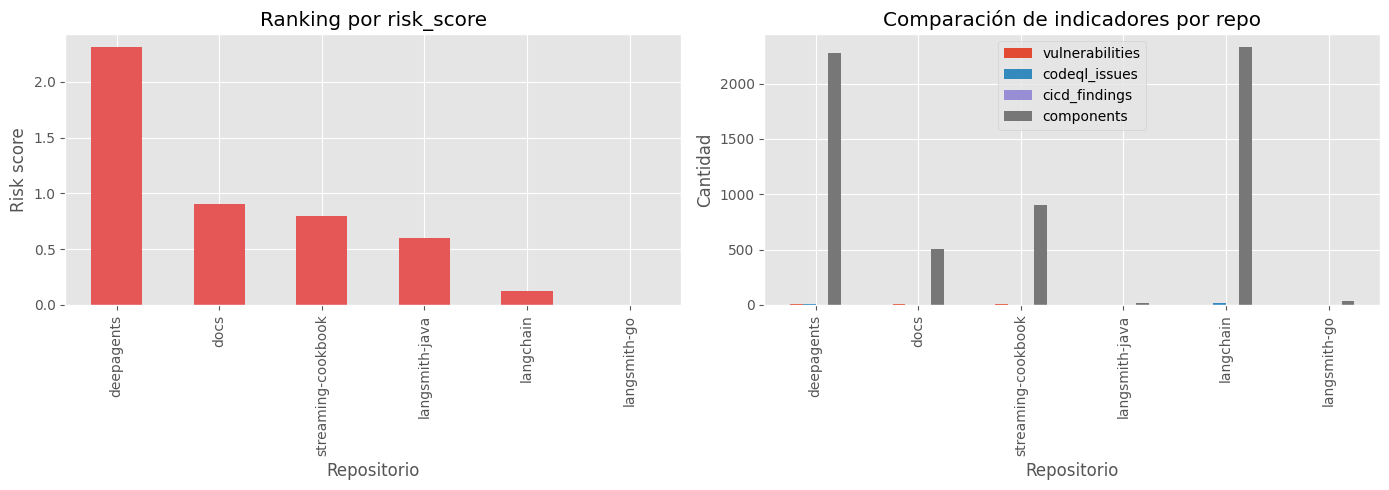

In [5]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_repo.empty:
    df_repo.plot.bar(x='name', y='risk_score', ax=axes[0], legend=False, color='#E45756')
    df_repo.set_index('name')[['vulnerabilities', 'codeql_issues', 'cicd_findings', 'components']].plot(kind='bar', ax=axes[1])
else:
    axes[0].text(0.5, 0.5, 'Sin datos', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'Sin datos', ha='center', va='center')

axes[0].set_title('Ranking por risk_score')
axes[0].set_xlabel('Repositorio')
axes[0].set_ylabel('Risk score')
axes[1].set_title('Comparación de indicadores por repo')
axes[1].set_xlabel('Repositorio')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## Hallazgos CI/CD

In [6]:
df_cicd

,repo,workflow,issue
0,deepagents,evals.yml,Permiso 'contents: write' innecesario
1,deepagents,release_please_parse_check.yml,Job 'parse-check': usa 'npm install' en vez de...
2,langchain,_refresh_model_profiles.yml,Permiso 'contents: write' innecesario
3,langchain,refresh_model_profiles.yml,Permiso 'contents: write' innecesario


In [7]:
# Conclusiones dinámicas
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_totals = {level: 0 for level in severity_order}

for repo in analysis.get('repositories', []) or []:
    by_sev = repo.get('vulnerabilities', {}).get('by_severity', {}) or {}
    for level in severity_order:
        try:
            severity_totals[level] += int(by_sev.get(level, 0) or 0)
        except (TypeError, ValueError):
            pass

top_repo = 'N/A'
top_risk = 0.0
if not df_repo.empty:
    top_repo = str(df_repo.iloc[0].get('name', 'N/A'))
    top_risk = float(df_repo.iloc[0].get('risk_score', 0.0) or 0.0)

most_common_severity = max(severity_totals, key=severity_totals.get) if severity_totals else 'Unknown'
total_high_critical = severity_totals.get('High', 0) + severity_totals.get('Critical', 0)
total_cicd = int(df_repo['cicd_findings'].sum()) if 'cicd_findings' in df_repo else 0

cwe_ranking = analysis.get('cross_repo_analysis', {}).get('common_weakness_ranking', []) or []
common_cwe = cwe_ranking[0]['cwe'] if cwe_ranking else 'N/A'

rule_counts = {}
for repo in analysis.get('repositories', []) or []:
    for rule_id, count in (repo.get('codeql', {}).get('by_rule', {}) or {}).items():
        try:
            rule_counts[rule_id] = rule_counts.get(rule_id, 0) + int(count or 0)
        except (TypeError, ValueError):
            continue
common_rule = max(rule_counts, key=rule_counts.get) if rule_counts else 'N/A'

print('Conclusiones dinámicas (riesgo y cierre):')
print(f'- Repo con mayor riesgo: {top_repo} ({top_risk:.2f})')
print(f'- Severidad predominante: {most_common_severity}')
print(f'- Total High/Critical: {total_high_critical}')
print(f'- Total hallazgos CI/CD: {total_cicd}')
print(f'- CWE más común: {common_cwe}')
print(f'- Regla CodeQL más común: {common_rule}')

Conclusiones dinámicas (riesgo y cierre):
- Repo con mayor riesgo: deepagents (2.31)
- Severidad predominante: Medium
- Total High/Critical: 6
- Total hallazgos CI/CD: 4
- CWE más común: CWE-200
- Regla CodeQL más común: py/clear-text-logging-sensitive-data


## Limitaciones técnicas

- **CodeQL**: cobertura dependiente de build/autobuild y lenguajes del repositorio.
- **Syft/Grype**: la calidad del inventario depende de manifests y lockfiles presentes.
- **CI/CD**: los hallazgos son heurísticos y no sustituyen revisión manual de workflows.

## Recomendaciones

- Priorizar remediación por `risk_score` y `vulnerability_density`.
- Atender primero vulnerabilidades **High/Critical**.
- Corregir permisos excesivos en workflows y fortalecer principio de mínimo privilegio.
- Migrar `npm install` a `npm ci` en pipelines cuando aplique.
- Atacar dependencias con fix disponible para reducir riesgo rápidamente.